*Aprendizaje Profundo*  
*Clasificador Perros y Gatos*  
*Autor:* Ing. Daniel Eduardo González Alvarado  
*Profesor:* Dr. Sebastian Salazar

# Cargar Librerias

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import load_img, img_to_array
import pathlib

# Cargar DB (Imagenes Entrenamiento)

In [ ]:

# Ruta a tu carpeta principal (la que tiene cats/ y dogs/)
data_dir = pathlib.Path("./DB/cats_and_dogs_small")


In [ ]:
img_height = 180
img_width = 180
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Clases:", class_names)


Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
Clases: ['cats', 'dogs']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
num_classes = 1
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='sigmoid')  # salida binaria
])

model.summary()


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # clasificación binaria
    metrics=['accuracy']
)

epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


# Guardar Modelo

In [ ]:
#model.save("modelo_gatos_perros.h5")
#model.save("modelo_gatos_perros")


# Cargar Modelo

In [10]:
from tensorflow.keras.models import load_model

model = load_model("./modelos/modelo_gatos_perros.keras")


C:\Users\death\AppData\Roaming\Python\Python312\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Informacion de Carga

In [ ]:
print("Input shape del modelo:", model.input_shape)

Input shape del modelo: (None, 500, 500, 3)


# Prueba Manual

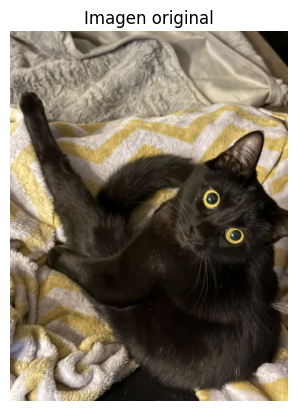

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicción: gato  (score = 0.000)


In [ ]:
# Obtener tamaño correcto desde el modelo
_, h, w, c = model.input_shape  # None, H, W, 3

img_path = "./img/blaky.jpeg"

# Imagen original
img_show = load_img(img_path)
plt.imshow(img_show)
plt.axis("off")
plt.title("Imagen original")
plt.show()

# Redimensionando al tamaño del modelo
img = load_img(img_path, target_size=(h, w))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # (1, h, w, 3)
#plt.imshow(img)
#plt.axis("off")
#plt.title("Imagen redimensionada")
#plt.show()

# Predicción
pred = model.predict(img_array)[0][0]

if pred > 0.5:
    print("Predicción: perro (score = {:.3f})".format(pred))
else:
    print("Predicción: gato  (score = {:.3f})".format(pred))
